# Water and Energy Sustainability Analysis

This notebook analyzes freshwater withdrawal and electricity generation trends across countries over time.

Important note:

- These datasets are not explicitly AI-only datasets.
- They are used as country-level proxy/background datasets to understand the resource environment in which digital infrastructure and data centres operate.
- Direct AI/data-centre-specific evidence will be supported in the recommendation section using external sources such as IEA and EU data-centre reporting material.


In [9]:
pip install matplotlib pandas


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [10]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://data360files.worldbank.org/data360-data/data/WB_WDI/WB_WDI_ER_H2O_FWTL_K3.csv"

df = pd.read_csv(url)

df.head()

,STRUCTURE,STRUCTURE_ID,ACTION,FREQ,REF_AREA,INDICATOR,SEX,AGE,URBANISATION,UNIT_MEASURE,COMP_BREAKDOWN_1,COMP_BREAKDOWN_2,COMP_BREAKDOWN_3,TIME_PERIOD,AGG_METHOD,UNIT_TYPE,DECIMALS,DATABASE_ID,TIME_FORMAT,COMMENT_TS,UNIT_MULT,DATA_SOURCE,OBS_CONF,OBS_VALUE,OBS_STATUS,FREQ_LABEL,REF_AREA_LABEL,INDICATOR_LABEL,SEX_LABEL,AGE_LABEL,URBANISATION_LABEL,UNIT_MEASURE_LABEL,COMP_BREAKDOWN_1_LABEL,COMP_BREAKDOWN_2_LABEL,COMP_BREAKDOWN_3_LABEL,AGG_METHOD_LABEL,UNIT_TYPE_LABEL,DECIMALS_LABEL,DATABASE_ID_LABEL,TIME_FORMAT_LABEL,UNIT_MULT_LABEL,OBS_STATUS_LABEL,OBS_CONF_LABEL
0,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,VEN,WB_WDI_ER_H2O_FWTL_K3,_T,_T,_T,M3,_Z,_Z,_Z,2011,_Z,NUMBER,2,WB_WDI,P1Y,"Annual freshwater withdrawals, total (billion ...",9,WB_WDI,PU,22.6211,A,Annual,"Venezuela, RB","Annual freshwater withdrawals, total (billion ...",Total,All age ranges or no breakdown by age,Total,Cubic meters,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Number (real number),Two,World Development Indicators (WDI),Annual,Billions,Normal value,Public
1,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,VNM,WB_WDI_ER_H2O_FWTL_K3,_T,_T,_T,M3,_Z,_Z,_Z,2011,_Z,NUMBER,2,WB_WDI,P1Y,"Annual freshwater withdrawals, total (billion ...",9,WB_WDI,PU,81.8620,A,Annual,Vietnam,"Annual freshwater withdrawals, total (billion ...",Total,All age ranges or no breakdown by age,Total,Cubic meters,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Number (real number),Two,World Development Indicators (WDI),Annual,Billions,Normal value,Public
2,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,PSE,WB_WDI_ER_H2O_FWTL_K3,_T,_T,_T,M3,_Z,_Z,_Z,2011,_Z,NUMBER,2,WB_WDI,P1Y,"Annual freshwater withdrawals, total (billion ...",9,WB_WDI,PU,0.2669,A,Annual,West Bank and Gaza,"Annual freshwater withdrawals, total (billion ...",Total,All age ranges or no breakdown by age,Total,Cubic meters,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Number (real number),Two,World Development Indicators (WDI),Annual,Billions,Normal value,Public
3,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,YEM,WB_WDI_ER_H2O_FWTL_K3,_T,_T,_T,M3,_Z,_Z,_Z,2011,_Z,NUMBER,2,WB_WDI,P1Y,"Annual freshwater withdrawals, total (billion ...",9,WB_WDI,PU,3.5650,A,Annual,"Yemen, Rep.","Annual freshwater withdrawals, total (billion ...",Total,All age ranges or no breakdown by age,Total,Cubic meters,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Number (real number),Two,World Development Indicators (WDI),Annual,Billions,Normal value,Public
4,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,ZMB,WB_WDI_ER_H2O_FWTL_K3,_T,_T,_T,M3,_Z,_Z,_Z,2011,_Z,NUMBER,2,WB_WDI,P1Y,"Annual freshwater withdrawals, total (billion ...",9,WB_WDI,PU,1.5720,A,Annual,Zambia,"Annual freshwater withdrawals, total (billion ...",Total,All age ranges or no breakdown by age,Total,Cubic meters,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Number (real number),Two,World Development Indicators (WDI),Annual,Billions,Normal value,Public


We begin with a cleaned water dataset.

To enhance the analysis, we add an energy dataset as a proxy for data centre and infrastructure growth.

This allows us to explore:

How energy demand is evolving over time
Whether water usage follows similar trends


In [11]:
water_df = df[["REF_AREA_LABEL", "TIME_PERIOD", "OBS_VALUE", "INDICATOR_LABEL"]].copy()

print("Before rename:")
print(water_df.columns.tolist())

water_df = water_df.rename(columns={
    "REF_AREA_LABEL": "Country",
    "TIME_PERIOD": "Year",
    "OBS_VALUE": "Water_Withdrawal",
    "INDICATOR_LABEL": "Indicator"
})

print("After rename:")
print(water_df.columns.tolist())

water_df["Year"] = pd.to_numeric(water_df["Year"], errors="coerce")
water_df["Water_Withdrawal"] = pd.to_numeric(water_df["Water_Withdrawal"], errors="coerce")

water_df = water_df.dropna(subset=["Year", "Water_Withdrawal"])
water_df["Year"] = water_df["Year"].astype(int)

print(water_df.head())
print(water_df.info())

Before rename:
['REF_AREA_LABEL', 'TIME_PERIOD', 'OBS_VALUE', 'INDICATOR_LABEL']
After rename:
['Country', 'Year', 'Water_Withdrawal', 'Indicator']
              Country  Year  Water_Withdrawal                                          Indicator
0       Venezuela, RB  2011           22.6211  Annual freshwater withdrawals, total (billion ...
1             Vietnam  2011           81.8620  Annual freshwater withdrawals, total (billion ...
2  West Bank and Gaza  2011            0.2669  Annual freshwater withdrawals, total (billion ...
3         Yemen, Rep.  2011            3.5650  Annual freshwater withdrawals, total (billion ...
4              Zambia  2011            1.5720  Annual freshwater withdrawals, total (billion ...
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6711 entries, 0 to 6710
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Country           6711 non-null   object 
 1   Year              

## What is freshwater withdrawal?

The water dataset uses the World Bank indicator ER.H2O.FWTL.K3, which measures annual freshwater withdrawals, total, in billion cubic meters.

Freshwater withdrawal refers to the total amount of water taken from rivers, lakes, reservoirs, groundwater, and in some cases desalination sources for use. This is a withdrawal measure, not necessarily permanent consumption.


In [12]:
energy = pd.read_csv("https://raw.githubusercontent.com/owid/energy-data/master/owid-energy-data.csv")

In [13]:
print(energy.columns.tolist())

['country', 'year', 'iso_code', 'population', 'gdp', 'biofuel_cons_change_pct', 'biofuel_cons_change_twh', 'biofuel_cons_per_capita', 'biofuel_consumption', 'biofuel_elec_per_capita', 'biofuel_electricity', 'biofuel_share_elec', 'biofuel_share_energy', 'carbon_intensity_elec', 'coal_cons_change_pct', 'coal_cons_change_twh', 'coal_cons_per_capita', 'coal_consumption', 'coal_elec_per_capita', 'coal_electricity', 'coal_prod_change_pct', 'coal_prod_change_twh', 'coal_prod_per_capita', 'coal_production', 'coal_share_elec', 'coal_share_energy', 'electricity_demand', 'electricity_demand_per_capita', 'electricity_generation', 'electricity_share_energy', 'energy_cons_change_pct', 'energy_cons_change_twh', 'energy_per_capita', 'energy_per_gdp', 'fossil_cons_change_pct', 'fossil_cons_change_twh', 'fossil_elec_per_capita', 'fossil_electricity', 'fossil_energy_per_capita', 'fossil_fuel_consumption', 'fossil_share_elec', 'fossil_share_energy', 'gas_cons_change_pct', 'gas_cons_change_twh', 'gas_consu

The energy dataset contains many variables.
We select only the relevant columns:

country → location
year → time dimension
electricity_generation → energy proxy

We then:

rename columns for consistency
remove missing values
ensure correct data types

This ensures compatibility with the water dataset.


## What does electricity_generation mean?

The OWID electricity data uses total electricity generation, measured in terawatt-hours (TWh).

This is not an AI-only measure. Instead, it provides a country-level energy backdrop that helps compare where electricity systems are larger, cleaner, or more fossil-dependent.


In [14]:
energy_df = energy[["country", "year", "electricity_generation"]].copy()

energy_df = energy_df.rename(columns={
    "country": "Country",
    "year": "Year",
    "electricity_generation": "Electricity"
})

energy_df = energy_df.dropna()
energy_df["Year"] = energy_df["Year"].astype(int)

print(energy_df.head())
print(energy_df.info())

         Country  Year  Electricity
0  ASEAN (Ember)  2000       378.61
1  ASEAN (Ember)  2001       404.85
2  ASEAN (Ember)  2002       433.19
3  ASEAN (Ember)  2003       458.30
4  ASEAN (Ember)  2004       496.63
<class 'pandas.core.frame.DataFrame'>
Index: 7684 entries, 0 to 23230
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Country      7684 non-null   object 
 1   Year         7684 non-null   int64  
 2   Electricity  7684 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 240.1+ KB
None


## Why merge water and electricity?

Merging by Country and Year lets us compare whether countries with larger electricity systems also show higher freshwater withdrawal.

This does not prove AI causes water use. Instead, it helps us identify broad resource patterns and build a stronger sustainability story.


In [15]:
merged = pd.merge(
    water_df,
    energy_df,
    on=["Country", "Year"],
    how="inner"
)

print(merged.shape)
print(merged.head())

(4225, 5)
    Country  Year  Water_Withdrawal                                          Indicator  Electricity
0   Vietnam  2011         81.862000  Annual freshwater withdrawals, total (billion ...       101.51
1    Zambia  2011          1.572000  Annual freshwater withdrawals, total (billion ...        11.49
2  Zimbabwe  2011          3.482850  Annual freshwater withdrawals, total (billion ...         9.17
3    Zambia  2009          1.572000  Annual freshwater withdrawals, total (billion ...         9.89
4  Zimbabwe  2009          3.526425  Annual freshwater withdrawals, total (billion ...         7.29


In [16]:
print(merged["Country"].nunique())
print(merged["Year"].min(), merged["Year"].max())

157
1985 2022


We aggregate data globally by year to observe:

total water withdrawal
total electricity generation

This helps identify:

long-term trends
similarities or differences in growth patterns


In [17]:
global_data = merged.groupby("Year")[["Water_Withdrawal", "Electricity"]].sum().reset_index()

print(global_data.head())

   Year  Water_Withdrawal  Electricity
0  1985       2142.613666     6030.181
1  1986       2186.665527     6636.733
2  1987       2221.617051     7165.544
3  1988       2223.803410     7489.819
4  1989       2226.245133     7899.555


## Section 5: Global Aggregation by Year

We aggregate data globally by year to observe:

- Total water withdrawal
- Total electricity generation

This helps identify:

- Long-term trends
- Similarities or differences in growth patterns


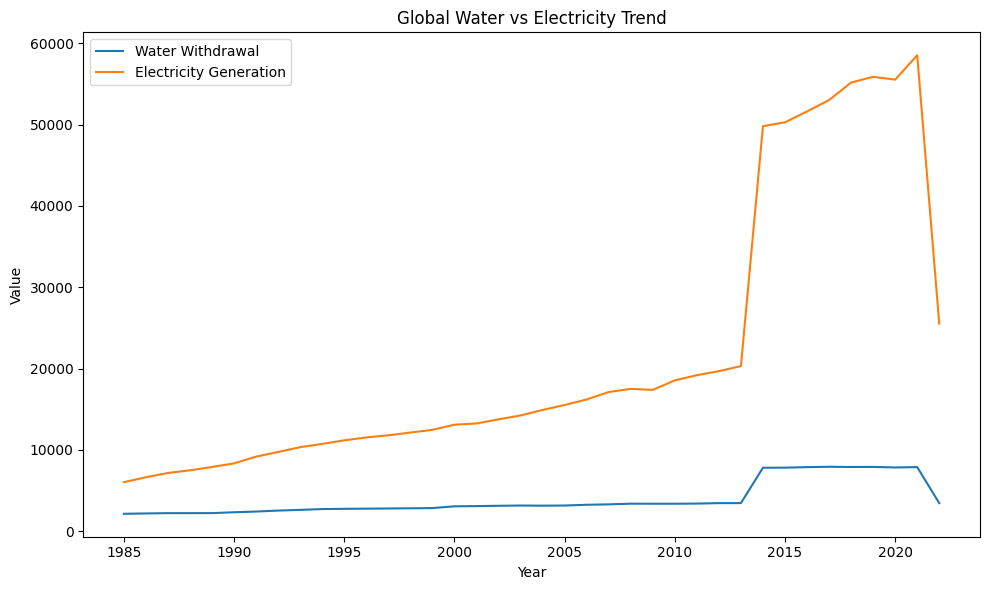

In [18]:
plt.figure(figsize=(10, 6))
plt.plot(global_data["Year"], global_data["Water_Withdrawal"], label="Water Withdrawal")
plt.plot(global_data["Year"], global_data["Electricity"], label="Electricity Generation")
plt.xlabel("Year")
plt.ylabel("Value")
plt.title("Global Water vs Electricity Trend")
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
global_data["Water_Index"] = global_data["Water_Withdrawal"] / global_data["Water_Withdrawal"].iloc[0] * 100
global_data["Energy_Index"] = global_data["Electricity"] / global_data["Electricity"].iloc[0] * 100

Water and energy values are on different scales.

To compare trends effectively, we normalize both variables:

Base year = 100
Convert values into indices

This allows us to clearly visualize relative growth over time.


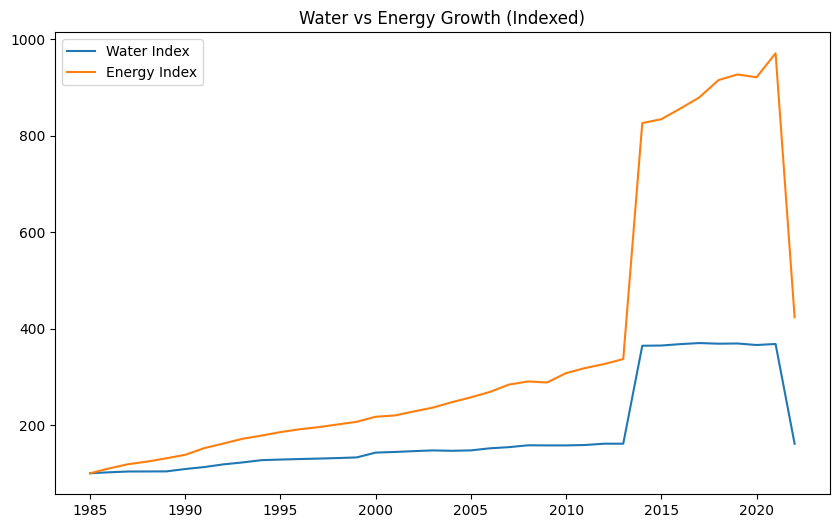

In [20]:
plt.figure(figsize=(10,6))
plt.plot(global_data["Year"], global_data["Water_Index"], label="Water Index")
plt.plot(global_data["Year"], global_data["Energy_Index"], label="Energy Index")
plt.legend()
plt.title("Water vs Energy Growth (Indexed)")
plt.show()

We identify the top countries based on total energy usage.

This helps answer:

Which countries dominate resource consumption?
Where are sustainability concerns most significant?

This step adds a geographical perspective to the analysis.


            Country  Water_Withdrawal  Electricity
153           World      31182.910345   206182.237
31            China      20992.770000   119889.577
108   North America       3839.541172    41889.050
74            Japan       3232.297333    38675.280
67            India      22743.444540    30137.948
27           Canada       1488.515850    21967.760
52           France       1194.394682    19433.594
55          Germany       1211.372955    18841.020
21           Brazil       2096.111095    15062.338
149  United Kingdom        400.196200    13237.452


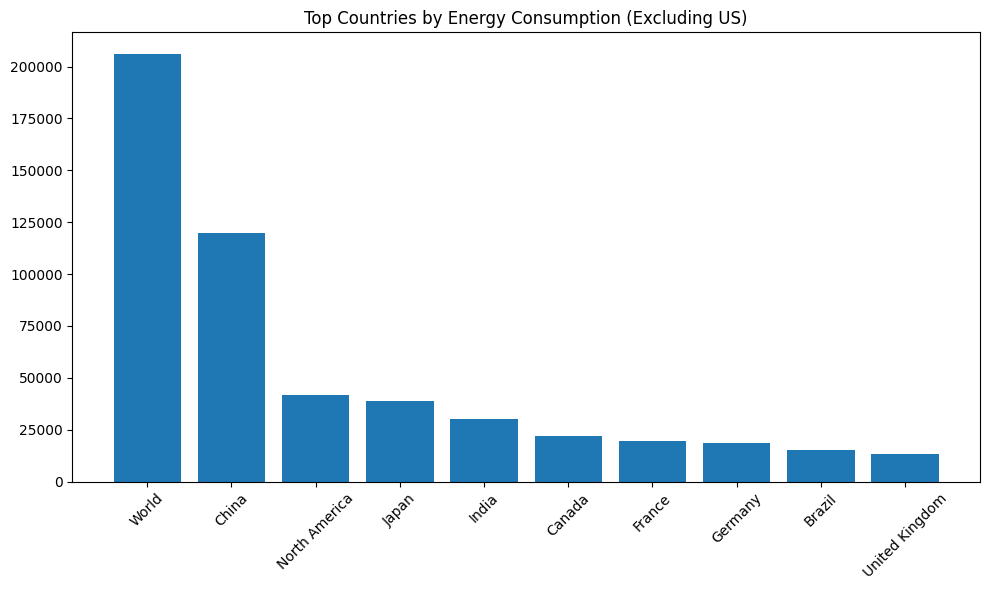

In [33]:
filtered = merged[merged["Country"] != "United States"]

top = filtered.groupby("Country")[["Water_Withdrawal", "Electricity"]].sum().reset_index()

top = top.sort_values(by="Electricity", ascending=False).head(10)

print(top)

plt.figure(figsize=(10,6))
plt.bar(top["Country"], top["Electricity"])
plt.xticks(rotation=45)
plt.title("Top Countries by Energy Consumption (Excluding US)")
plt.tight_layout()
plt.show()

We isolate data for Canada to provide a localized analysis.

This aligns with the project requirement to connect insights to a specific region or audience.

We analyze:

water usage trends
energy growth patterns


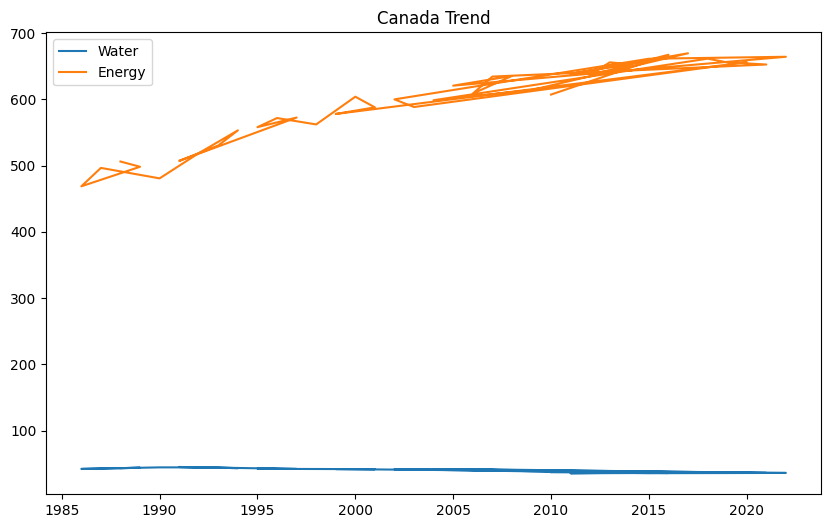

In [23]:
canada = merged[merged["Country"] == "Canada"]

plt.figure(figsize=(10,6))
plt.plot(canada["Year"], canada["Water_Withdrawal"], label="Water")
plt.plot(canada["Year"], canada["Electricity"], label="Energy")
plt.legend()
plt.title("Canada Trend")
plt.show()

We compute correlation between:

water withdrawal
electricity generation

This helps determine:

whether increases in energy demand are associated with higher water usage

This is a key analytical insight for sustainability discussions.


In [24]:
correlation = merged[["Water_Withdrawal", "Electricity"]].corr()
print(correlation)

                  Water_Withdrawal  Electricity
Water_Withdrawal          1.000000     0.939653
Electricity               0.939653     1.000000


In [25]:
energy_mix_df = energy[[
    "country",
    "year",
    "electricity_generation",
    "renewables_share_elec",
    "low_carbon_share_elec",
    "fossil_share_elec"
]].copy()

energy_mix_df = energy_mix_df.rename(columns={
    "country": "Country",
    "year": "Year",
    "electricity_generation": "Electricity",
    "renewables_share_elec": "Renewables_Share",
    "low_carbon_share_elec": "Low_Carbon_Share",
    "fossil_share_elec": "Fossil_Share"
})

energy_mix_df = energy_mix_df.dropna()
energy_mix_df["Year"] = energy_mix_df["Year"].astype(int)

merged_mix = pd.merge(
    water_df,
    energy_mix_df,
    on=["Country", "Year"],
    how="inner"
)

print(merged_mix.head())
print(merged_mix.shape)

    Country  Year  Water_Withdrawal                                          Indicator  Electricity  Renewables_Share  Low_Carbon_Share  Fossil_Share
0   Vietnam  2011         81.862000  Annual freshwater withdrawals, total (billion ...       101.51            40.577            40.577        59.423
1    Zambia  2011          1.572000  Annual freshwater withdrawals, total (billion ...        11.49            99.913            99.913         0.087
2  Zimbabwe  2011          3.482850  Annual freshwater withdrawals, total (billion ...         9.17            57.688            57.688        42.312
3    Zambia  2009          1.572000  Annual freshwater withdrawals, total (billion ...         9.89            99.899            99.899         0.101
4  Zimbabwe  2009          3.526425  Annual freshwater withdrawals, total (billion ...         7.29            75.720            75.720        24.280
(3948, 8)


             Country  Water_Withdrawal  Electricity  Renewables_Share  Low_Carbon_Share  Fossil_Share
3052           China        568.480000      8848.71            30.181            34.903        65.097
2797           India        647.500000      1806.14            20.258            22.815        77.185
2444           Japan         79.700000      1040.57            20.488            25.463        74.537
2626          Brazil         67.940000       677.16            87.703            89.853        10.147
2495          Canada         36.128000       664.08            68.135            81.180        18.820
2758         Germany         25.792569       566.88            44.373            50.496        49.504
2755          France         24.427660       468.25            24.169            87.112        12.888
3222    Saudi Arabia         23.380000       409.84             0.490             0.490        99.510
2615          Mexico         89.804000       340.15            24.439            2

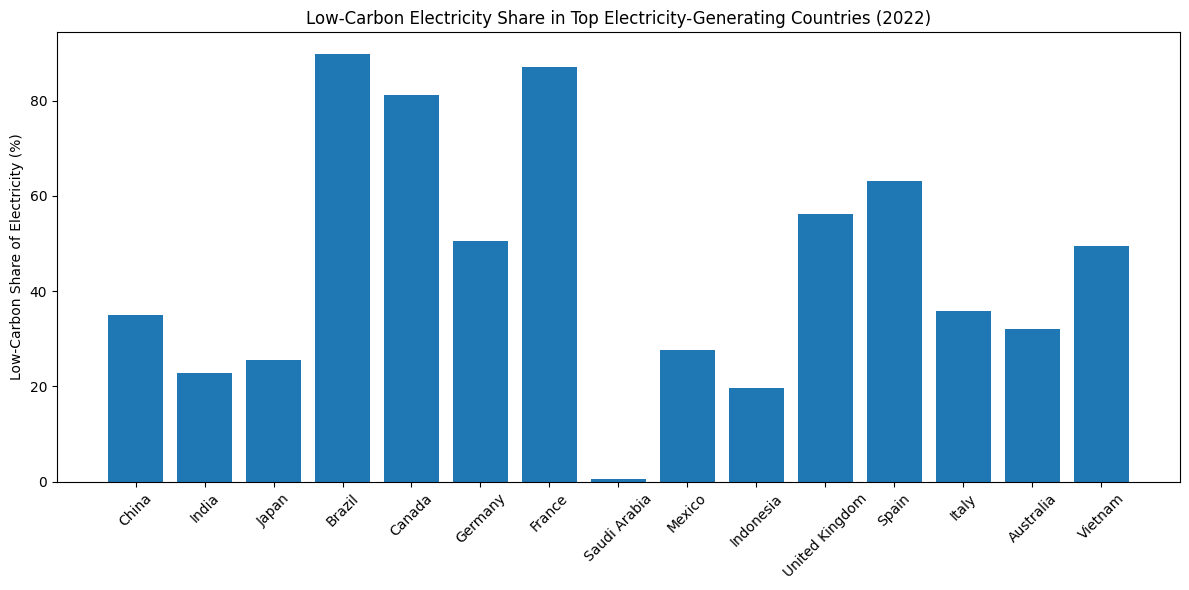

In [28]:
latest_data = latest_data[latest_data["Country"] != "United States"]

latest_top = latest_data[[
    "Country",
    "Water_Withdrawal",
    "Electricity",
    "Renewables_Share",
    "Low_Carbon_Share",
    "Fossil_Share"
]].sort_values(by="Electricity", ascending=False).head(15)

print(latest_top)

plt.figure(figsize=(12, 6))
plt.bar(latest_top["Country"], latest_top["Low_Carbon_Share"])
plt.xticks(rotation=45)
plt.ylabel("Low-Carbon Share of Electricity (%)")
plt.title(f"Low-Carbon Electricity Share in Top Electricity-Generating Countries ({latest_year})")
plt.tight_layout()
plt.show()

## Insight: not all electricity growth is equally sustainable

Electricity generation alone does not tell us whether a country is well-positioned for sustainable digital infrastructure growth.

By adding low-carbon, renewable, and fossil shares, we can distinguish between:

- countries with large electricity systems powered by cleaner sources
- countries with large electricity systems still heavily dependent on fossil fuels

This is more useful for recommendation-making than total electricity alone.


In [34]:
hosting_candidates = latest_data[
    (latest_data["Electricity"] > latest_data["Electricity"].median()) &
    (latest_data["Low_Carbon_Share"] > latest_data["Low_Carbon_Share"].median())
][[
    "Country", "Electricity", "Low_Carbon_Share", "Renewables_Share", "Fossil_Share", "Water_Withdrawal"
]].sort_values(by="Low_Carbon_Share", ascending=False)

print(hosting_candidates.head(10))

          Country  Electricity  Low_Carbon_Share  Renewables_Share  Fossil_Share  Water_Withdrawal
3444     Ethiopia        17.41           100.000           100.000         0.000          10.54810
2796      Iceland        19.87           100.000           100.000         0.000           0.29000
2605     Paraguay        44.11           100.000           100.000         0.000           2.41300
2600       Norway       145.42            98.645            98.645         1.355           2.68787
3346       Sweden       173.05            98.336            68.321         1.664           2.48300
3347  Switzerland        61.73            97.424            58.302         2.576           1.70400
3348   Tajikistan        21.49            92.694            92.694         7.306          10.60200
2626       Brazil       677.16            89.853            87.703        10.147          67.94000
1456       Zambia        19.47            88.906            88.906        11.094           1.57200
2754      

## Key findings from the quantitative analysis

1. The current datasets provide a country-level resource backdrop, not direct AI-only measurement.
2. Freshwater withdrawal and electricity generation together help frame sustainability pressure.
3. Electricity quantity alone is not enough; electricity mix matters.
4. Countries with stronger low-carbon electricity shares may be better candidates for future sustainable digital infrastructure expansion.
